In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Show all columns on output
pd.set_option('display.max_columns', 999)

In [ ]:
!pip install openpyxl
import openpyxl

## Data Exploration

In [ ]:
df = pd.read_excel("/content/online_retail_II.xlsx", sheet_name=0)

df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [ ]:
df.isnull().sum() / len(df)*100

,0
Invoice,0.000000
StockCode,0.000000
Description,0.557225
Quantity,0.000000
InvoiceDate,0.000000
Price,0.000000
Customer ID,20.539488
Country,0.000000


,0
Invoice,0.000000
StockCode,0.000000
Description,0.557225
Quantity,0.000000
InvoiceDate,0.000000
Price,0.000000
Customer ID,20.539488
Country,0.000000


### Initial Data Overview and Missing Values

From `df.info()` and `df.isnull().sum()`, we observe that:
*   `Description` has a small percentage of missing values (0.56%).
*   `Customer ID` has a significant number of missing values (20.54%).

`df.describe()` reveals that:
*   `Quantity` has negative values, indicating returned items or cancelled orders.
*   `Price` also contains negative values, which need investigation as prices should generally be positive.

In [ ]:
df = df.astype({
    'Invoice': 'string',
    'StockCode': 'string',
    'Description': 'string',
    'Quantity': 'int32',
    'Price': 'float32',
    'Customer ID': 'float32',
    'Country': 'category'})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  string        
 1   StockCode    525461 non-null  string        
 2   Description  522533 non-null  string        
 3   Quantity     525461 non-null  int32         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float32       
 6   Customer ID  417534 non-null  float32       
 7   Country      525461 non-null  category      
dtypes: category(1), datetime64[ns](1), float32(2), int32(1), string(3)
memory usage: 22.6 MB


### Data Type Conversion

Converting data types to more appropriate formats (e.g., `string`, `int32`, `float32`, `category`) helps optimize memory usage and ensures that operations are performed correctly. For instance, `Customer ID` is converted to `float32` as it contains `NaN` values and `category` for `Country`.

In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.646484
min,-9600.000000,2009-12-01 07:45:00,-53594.359375,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.089844,18287.000000
std,107.424110,NaN,146.098755,1680.852295


In [ ]:
df.describe(include=['string','category'])

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


### Identifying Anomalies: Negative Quantity, Invoice Patterns, and Stock Codes

We investigate rows where `Quantity` is negative, as these usually represent returns or cancellations. These rows often have `Invoice` numbers starting with 'C' (e.g., C489449). We also look for other patterns in `Invoice` numbers that are not purely numerical, and patterns in `StockCode` to identify non-product entries.

In [ ]:
df[df["Customer ID"].isnull()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,<NA>,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [ ]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [ ]:
# Finding rows that are not purely 6-digit numerical Invoice
df[df["Invoice"].str.match(r"^\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [ ]:
# finding Invoice not starting with C , also not purely numerical
df[~df['Invoice'].str.match(r"^C?\d{6}$")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.359375,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.789062,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.871094,NaN,United Kingdom


In [ ]:
df[df['Invoice'].str.match(r"^C+\d{6}$")].shape[0]/len(df)*100

1.9422944804657245

Total cancelled transaction rows are around 10k.

### Analysis of Non-Standard Invoices and Stock Codes

Further investigation into `Invoice` and `StockCode` columns reveals non-standard entries:

*   **Invoice Patterns**: Invoices starting with 'C' indicate cancelled transactions. There are also a few invoices starting with 'A', which represent 'Adjust bad debt' transactions, often with negative prices and null `Customer ID`s.
*   **StockCode Patterns**: Many `StockCode` entries are not purely numerical or alphanumeric (e.g., 'POST', 'DOT', 'M', 'BANK CHARGES', 'TEST', 'GIFT'). These entries often represent non-product transactions (e.g., postage, manual adjustments, test items, gift cards) and frequently have zero or negative prices, and sometimes null `Customer ID`s. These will be excluded from the analysis to focus on actual product sales.

In [ ]:
df[df['Invoice']=='528059']
#checked all these codes without A and with C, NO MATCH FOUND


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [ ]:
#Finding StcokCodes that are not purely numerical.
df[~df['StockCode'].str.match(r"^\d{5}$")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
12,489436,48173C,DOOR MAT BLACK FLOCK,10,2009-12-01 09:06:00,5.95,13078.0,United Kingdom
23,489436,35004B,SET OF 3 BLACK FLYING DUCKS,12,2009-12-01 09:06:00,4.65,13078.0,United Kingdom
28,489436,84596F,SMALL MARSHMALLOWS PINK BOWL,8,2009-12-01 09:06:00,1.25,13078.0,United Kingdom
...,...,...,...,...,...,...,...,...
525387,538170,84029E,RED WOOLLY HOTTIE WHITE HEART.,2,2010-12-09 19:32:00,3.75,13969.0,United Kingdom
525388,538170,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,2,2010-12-09 19:32:00,3.75,13969.0,United Kingdom
525389,538170,85232B,SET OF 3 BABUSHKA STACKING TINS,2,2010-12-09 19:32:00,4.95,13969.0,United Kingdom
525435,538171,47591D,PINK FAIRY CAKE CHILDRENS APRON,1,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [ ]:
#Removing all the digits from the StockCode to see how many alphabets
#and other characters are there
sc_array = df['StockCode'].str.replace(r"\d","",regex=True).unique()
sc_array

<StringArray>
[            '',            'P',            'W',            'C',
            'B',            'F',            'L',            'S',
            'A',            'N',         'POST',            'E',
            'J',            'D',            'G',           'LP',
           'BL',            'K',            'H',           'GR',
            'M',         'DCGS',          'DOT',            'U',
            'b',            'w',            'c',            'a',
            'f',           'bl',            's',            'p',
            'R',            'V',            'T',            'I',
 'BANK CHARGES',            'O',            'Z',         'TEST',
       'gift__',        'DCGSN',            'm',         'PADS',
            'Y',           'HC',            'e',            'd',
       'ADJUST',    'DCGSSGIRL',         'GIFT',     'DCGSLBOY',
            'k',            'g',     'DCGSSBOY',    'DCGSLGIRL',
            'j',            'l',            'n',           'J ',
           

In [ ]:
df[df['StockCode'].str.contains(r'[a-zA-Z]{1,2}')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
12,489436,48173C,DOOR MAT BLACK FLOCK,10,2009-12-01 09:06:00,5.95,13078.0,United Kingdom
23,489436,35004B,SET OF 3 BLACK FLYING DUCKS,12,2009-12-01 09:06:00,4.65,13078.0,United Kingdom
28,489436,84596F,SMALL MARSHMALLOWS PINK BOWL,8,2009-12-01 09:06:00,1.25,13078.0,United Kingdom
...,...,...,...,...,...,...,...,...
525387,538170,84029E,RED WOOLLY HOTTIE WHITE HEART.,2,2010-12-09 19:32:00,3.75,13969.0,United Kingdom
525388,538170,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,2,2010-12-09 19:32:00,3.75,13969.0,United Kingdom
525389,538170,85232B,SET OF 3 BABUSHKA STACKING TINS,2,2010-12-09 19:32:00,4.95,13969.0,United Kingdom
525435,538171,47591D,PINK FAIRY CAKE CHILDRENS APRON,1,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [ ]:
df1 = df.copy()

In [ ]:
df1[df1['StockCode'].str.contains('$B')]# will keep it, just remove those with Adjust invoices
df1[df1['StockCode'].str.contains('$A')] # will be included
df1[df1['StockCode'].str.contains('$LP')] # include
#df1[~df1['StockCode'].str.contains(r"^\d{5}")].value_counts().reset_index()
#df1[df1["StockCode"]=='79323LP'].value_counts().reset_index()
df1["StockCode"].value_counts().reset_index()
df1[df1['StockCode'].str.contains('$b')] # include
df1[df1['StockCode'].str.contains('DOT')]['Price'].mean() #exclude
df1[df1['StockCode'].str.contains('POST')]['Price'].mean() #exclude
df1[df1['StockCode'].str.contains('TEST')] # exclude -> test products
df1[df1['StockCode'].str.contains('PADS')] # exclude -> really low value, around 0
df1[df1['StockCode'].str.contains('BANK CHARGES')]['Price'].mean() # exclude
df1[df1['StockCode'].str.contains('gift_')] #exclude
df1[df1['StockCode'].str.contains('ADJUST')] #exclude
df1[df1['StockCode'].str.contains('GIFT')] # exclude
df1[df1['StockCode'].str.contains('AMAZONFEE')] #exclude
df1[df1['StockCode'].str.contains('DCGS')] #exclude-> all cust IDs are null.
df1[(df1['StockCode'].str.contains(r'J$')) & (df1['Quantity']<0)]
df1[df1['StockCode'].str.contains('J ')]['StockCode'] #only had 1 entry
df1[df1['StockCode'].str.contains('j')] # only had 2 entries
df1[(df1['StockCode'].str.contains('BL'))] # Display stock codes with 'bl'
df1['StockCode'] = df1['StockCode'].str.replace('bl', 'BL', regex=False) # Replace 'bl' with 'BL'
df1[(df1['StockCode'].str.contains('^m'))] # Display stock codes starting with 'm'-> manual transaction excluded
df1[(df1['StockCode'].str.contains('b'))] # nan customer IDs
df1['StockCode'] = df1['StockCode'].str.replace(r'f$', 'F', regex=True) # Change 'f' to 'F' only at the end
df1[(df1['StockCode'].str.contains('[gr]'))] # didnt find much
df1[(df1['StockCode'].str.contains('y'))] #nothing
df1['StockCode'] = df1['StockCode'].str.replace('k', 'K', regex=False)
df1[(df1['StockCode'].str.contains('SP'))] # ONLY 2
df1['StockCode'] = df1['StockCode'].str.replace('p$','P',regex=True) # Change 'p' to 'P' only at the end
df1['StockCode']= df1['StockCode'].str.replace('n','N',regex=False)
df1[(df1['StockCode'].str.contains('D'))] # contains discount and dotcom postage too, both will be excluded
df1[(df1['StockCode'].str.contains('W'))]
df1[(df1['StockCode'].str.contains('V'))]
df1[(df1['StockCode'].str.contains('O$'))]
df1[(df1['StockCode'].str.contains('HC'))] # ONLY 1
df1['StockCode'] = df1['StockCode'].str.replace('l$','L',regex=True)
df1[(df1['StockCode'].str.contains('G'))]
df1[(df1['StockCode'].str.contains('C'))]
df1[(df1['StockCode'].str.contains(r'^[0-9]*C[0-9]+$'))]# has C2 and C3 carriages, would be excluded
df1[(df1['StockCode'].str.contains('.*A.+'))]
df1[(df1['StockCode'].str.contains('.*B.+'))]
df1[(df1['StockCode'].str.contains('U'))]
df1[(df1['StockCode'].str.contains('.*U.+'))]
df1[(df1['StockCode'].str.contains('Z'))]
df1[(df1['StockCode'].str.contains('E'))]
df1[(df1['StockCode'].str.contains('I'))]


#df1[(df1['Invoice']=='C493898')]
#df1[df1['Customer ID']==13777.00]


#df1[df1['StockCode'].str.contains(r'^J[0-9]{,5}J*[0-9]{,5}$')]
#df1[df1['StockCode'].str.contains('DOT')]['StockCode
#df1[(df1['StockCode'].str.contains(r'[0-9]M$') & (df1['Quantity']<0))]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
15659,C490700,90214I,"LETTER ""I"" BLING KEY RING",-6,2009-12-07 14:37:00,1.25,14695.0,United Kingdom
21879,491118,90214I,"LETTER ""I"" BLING KEY RING",1,2009-12-09 15:03:00,1.25,16933.0,United Kingdom
27785,491717,90214I,"LETTER ""I"" BLING KEY RING",1,2009-12-13 15:54:00,1.25,16725.0,United Kingdom
36612,492414,90214I,"LETTER ""I"" BLING KEY RING",1,2009-12-16 17:01:00,2.57,NaN,United Kingdom
74052,496076,84596I,<NA>,72,2010-01-28 17:47:00,0.00,NaN,United Kingdom
80231,496722,DCGSSGIRL,<NA>,-1,2010-02-03 14:04:00,0.00,NaN,United Kingdom
83304,497107,GIFT,<NA>,-9,2010-02-05 15:18:00,0.00,NaN,United Kingdom
97529,498549,84596I,WRAP SWEETS LIGHT PINK SMALL BOWL,1,2010-02-19 18:04:00,2.51,NaN,United Kingdom
101693,499042,DCGSLGIRL,<NA>,-57,2010-02-24 13:31:00,0.00,NaN,United Kingdom
109955,499965,84596I,WRAP SWEETS LIGHT PINK SMALL BOWL,1,2010-03-03 13:57:00,1.25,16461.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
15659,C490700,90214I,"LETTER ""I"" BLING KEY RING",-6,2009-12-07 14:37:00,1.25,14695.0,United Kingdom
21879,491118,90214I,"LETTER ""I"" BLING KEY RING",1,2009-12-09 15:03:00,1.25,16933.0,United Kingdom
27785,491717,90214I,"LETTER ""I"" BLING KEY RING",1,2009-12-13 15:54:00,1.25,16725.0,United Kingdom
36612,492414,90214I,"LETTER ""I"" BLING KEY RING",1,2009-12-16 17:01:00,2.57,NaN,United Kingdom
74052,496076,84596I,<NA>,72,2010-01-28 17:47:00,0.00,NaN,United Kingdom
80231,496722,DCGSSGIRL,<NA>,-1,2010-02-03 14:04:00,0.00,NaN,United Kingdom
83304,497107,GIFT,<NA>,-9,2010-02-05 15:18:00,0.00,NaN,United Kingdom
97529,498549,84596I,WRAP SWEETS LIGHT PINK SMALL BOWL,1,2010-02-19 18:04:00,2.51,NaN,United Kingdom
101693,499042,DCGSLGIRL,<NA>,-57,2010-02-24 13:31:00,0.00,NaN,United Kingdom
109955,499965,84596I,WRAP SWEETS LIGHT PINK SMALL BOWL,1,2010-03-03 13:57:00,1.25,16461.0,United Kingdom


In [ ]:
df1[(df1["StockCode"].str.match(r"^\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()
# double checking

<StringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'gift_0001_80',     'DCGS0072', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST', 'gift_0001_40',
 'gift_0001_60', 'gift_0001_70', 'gift_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',            'm',     'DCGS0053',
     'DCGS0062',     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
            'B',     'DCGS0041',      'ADJUST2',      '47503J ',
           'C3',       'SP1002',    'AMAZONFEE']
Length: 55, dtype: string

In [ ]:
df1.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


### Notes

#### Stock Code
* StockCode is meant to follow the pattern `[0-9]{5}` but seems to have legit values for `[0-9]{5}[a-zA-Z]+`
    * Also contains other values:
        | **Code**            | **Description**                                                        | **Action**              |
        |---------------------|------------------------------------------------------------------------|-------------------------|
        | DCGS            | Looks valid, some quantities are negative though and customer ID is null | Exclude from clustering |
        | D               | Looks valid, represents discount values                                | Exclude from clustering |
        | DOT             | Looks valid, represents postage charges                                | Exclude from clustering |
        | M or m          | Looks valid, represents manual transactions                            | Exclude from clustering |
        | C2              | Carriage transaction - not sure what this means                        | Exclude from clustering |
        | C3              | Not sure, only 1 transaction                                           | Exclude                 |
        | BANK CHARGES or B | Bank charges                                                        | Exclude from clustering |
        | S               | Samples sent to customer                                               | Exclude from clustering |
        | TESTXXX         | Testing data, not valid                                                | Exclude from clustering |
        | gift__XXX       | Purchases with gift cards, might be interesting for another analysis, but no customer data | Exclude |
        | PADS            | Looks like a legit stock code for padding but 0 price                             | Exclude                 |
        | SP1002          | Looks like a special request item, only 2 transactions, 3 look legit, 1 has 0 pricing | Exclude for now|
        | AMAZONFEE       | Looks like fees for Amazon shipping or something                       | Exclude for now         |
        | ADJUSTX         | Looks like manual account adjustments by admins                        | Exclude for now         |

## Data Cleaning

In [ ]:
mask = (df1["Invoice"].str.match("^\\d{6}$") == True)

df1 = df1[mask]
df1

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
mask2 = (
        (df1["StockCode"].str.match("^\\d{5}$") == True)|
         (df1["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == True)
         )
df1 = df1[mask2]
df1

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
df1.dropna(subset=["Customer ID"], inplace=True)
df1

/tmp/ipykernel_4614/2811322249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.dropna(subset=["Customer ID"], inplace=True)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
df1.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406323.000000,406323,406323.000000,406323.000000
mean,13.619534,2010-07-01 10:14:46.649094656,2.991564,15373.658203
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14004.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.002302,NaN,4.285174,1677.391846


In [ ]:
df1[df1['Invoice'].str.match(r"^A")]
# all adjusted removed with null cust ids and also all negative quantities have been removed too

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [ ]:
 df1[df1["Price"] == 0]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom
111348,500073,21662,VINTAGE GLASS COFFEE CADDY,1,2010-03-04 11:44:00,0.0,13047.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom
111348,500073,21662,VINTAGE GLASS COFFEE CADDY,1,2010-03-04 11:44:00,0.0,13047.0,United Kingdom


In [ ]:
df1 = df1[df1["Price"] > 0.0]

In [ ]:
df1.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406295.000000,406295,406295.000000,406295.000000
mean,13.618359,2010-07-01 10:18:05.997415424,2.991771,15373.751953
min,1.000000,2009-12-01 07:45:00,0.030000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14006.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.000476,NaN,4.285237,1677.367310


In [ ]:
df1["Price"].min()

0.029999999329447746

In [ ]:
len(df1)/len(df)

0.7732162805612596

### Summary of Data Cleaning Steps

We performed several critical cleaning steps:
1.  **Filtered Invoices**: Removed cancelled transactions (Invoice starting with 'C') and invalid invoices (Invoice starting with 'A').
2.  **Cleaned Stock Codes**: Excluded entries that do not correspond to actual products based on their patterns and descriptions (e.g., 'POST', 'DOT', 'M', 'BANK CHARGES', 'TEST', 'GIFT', 'ADJUST', 'AMAZONFEE', 'DCGS' codes).
3.  **Removed Missing Customer IDs**: Dropped rows where `Customer ID` was null, as these cannot be attributed to a specific customer for segmentation.
4.  **Removed Zero/Negative Prices**: Excluded transactions where `Price` was zero or negative, ensuring only valid sales transactions are considered.

These cleaning steps resulted in dropping approximately 23% of the original records, ensuring a dataset suitable for customer segmentation based on purchase behavior.

###We didnt need to remove each and every pointer individually, all were removed at once when we filtered rows with price > 0

In [ ]:
cleaned_df = df1.copy()
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


Dropped about 23% of records during cleaning

### Creating `SalesLineTotal`

To calculate the total revenue for each line item, we multiply `Quantity` by `Price`. This `SalesLineTotal` will be used to derive the `MonetaryValue` for RFM analysis.

## Feature Engineering

In [ ]:
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.399998
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.000000
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.000000
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.799995
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.000000
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.900000
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.750000
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.750000
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.500000


### RFM Feature Aggregation

We aggregate the cleaned transaction data (`cleaned_df`) by `Customer ID` to create the core RFM (Recency, Frequency, Monetary) features:

*   **MonetaryValue**: The sum of `SalesLineTotal` for each customer, representing the total amount of money spent by the customer.
*   **Frequency**: The number of unique `Invoice` numbers for each customer, representing how often a customer purchases.
*   **LastInvoiceDate**: The most recent `InvoiceDate` for each customer, used to calculate `Recency`.

This aggregation transforms the transaction-level data into customer-level features essential for segmentation.

In [ ]:
aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False) \
.agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max")
    )

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.359995,2,2010-06-28 13:53:00
1,12347.0,1323.320001,2,2010-12-07 14:57:00
2,12348.0,221.160004,1,2010-09-27 14:59:00
3,12349.0,2221.139987,2,2010-10-28 08:23:00
4,12351.0,300.929998,1,2010-11-29 15:23:00


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.359995,2,2010-06-28 13:53:00
1,12347.0,1323.320001,2,2010-12-07 14:57:00
2,12348.0,221.160004,1,2010-09-27 14:59:00
3,12349.0,2221.139987,2,2010-10-28 08:23:00
4,12351.0,300.929998,1,2010-11-29 15:23:00


In [ ]:
max_invoice_date = aggregated_df["LastInvoiceDate"].max()

aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.359995,2,2010-06-28 13:53:00,164
1,12347.0,1323.320001,2,2010-12-07 14:57:00,2
2,12348.0,221.160004,1,2010-09-27 14:59:00,73
3,12349.0,2221.139987,2,2010-10-28 08:23:00,42
4,12351.0,300.929998,1,2010-11-29 15:23:00,10


### Calculating Recency

`Recency` is calculated as the number of days since the customer's last purchase. We determine the `max_invoice_date` from the entire dataset to serve as the reference point (today's date, effectively) and subtract each customer's `LastInvoiceDate` from it. A lower `Recency` value indicates a more recently active customer.

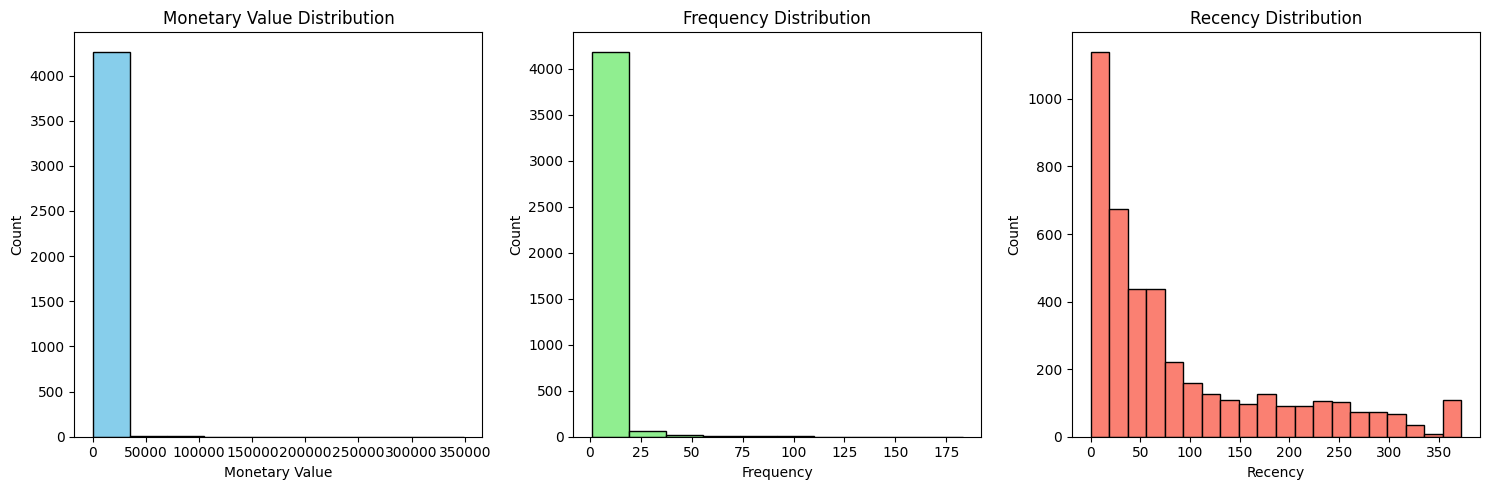

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(aggregated_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

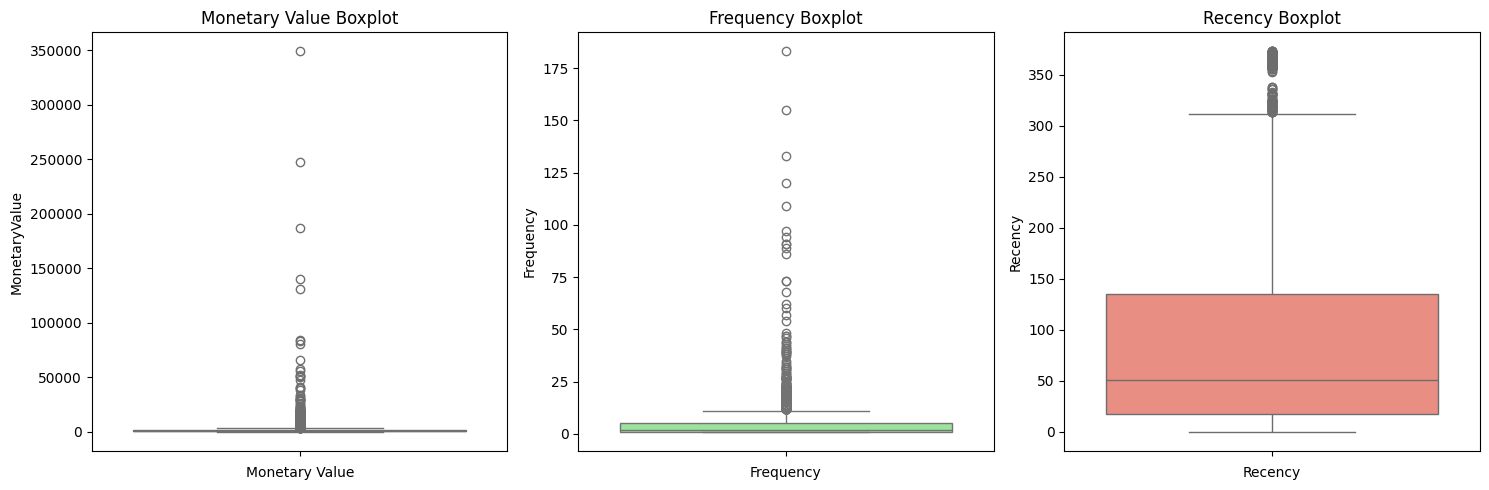

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

### Visualizing RFM Feature Distributions

Histograms and box plots are used to visualize the distribution of `MonetaryValue`, `Frequency`, and `Recency`. These plots help us understand the spread, skewness, and presence of outliers in each RFM feature.

**Insights from RFM Distributions:**
*   **MonetaryValue**: Highly skewed to the right, with a large number of customers having low monetary values and a few high-value customers.
*   **Frequency**: Also skewed to the right, showing that most customers make a few purchases, while a small group purchases very frequently.
*   **Recency**: Appears to be less skewed than MonetaryValue and Frequency, but still indicates that many customers have purchased recently, while some have not purchased for a long time.

These visualizations confirm the presence of significant outliers, especially in `MonetaryValue` and `Frequency`, which need to be addressed before clustering to ensure that extreme values do not disproportionately influence the clustering algorithm.

In [ ]:
M_Q1 = aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3 = aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR = M_Q3 - M_Q1

monetary_outliers_df = aggregated_df[(aggregated_df["MonetaryValue"] > (M_Q3 + 1.5 * M_IQR)) | (aggregated_df["MonetaryValue"] < (M_Q1 - 1.5 * M_IQR))].copy()

monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.000000,423.000000,423.000000,423,423.000000
mean,15103.040039,12188.101672,17.167849,2010-11-09 12:26:02.978723328,30.035461
min,12357.000000,3802.039994,1.000000,2009-12-10 18:03:00,0.000000
25%,13622.000000,4605.939990,8.000000,2010-11-08 13:17:30,3.000000
50%,14961.000000,6191.319971,12.000000,2010-11-26 12:19:00,13.000000
75%,16692.000000,10273.234947,18.000000,2010-12-06 10:34:30,31.000000
max,18260.000000,349164.349790,183.000000,2010-12-09 19:32:00,364.000000
std,1728.661133,25830.850969,19.729755,NaN,51.541004


In [ ]:
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1

frequency_outliers_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR)) | (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()

frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.656250,14409.714844,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1094.389988,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4331.559979,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6615.770066,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11692.404962,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,349164.349790,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429688,31381.736692,21.932937,NaN,26.589117


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.656250,14409.714844,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1094.389988,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4331.559979,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6615.770066,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11692.404962,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,349164.349790,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429688,31381.736692,21.932937,NaN,26.589117


### Outlier Detection and Separation

We use the Interquartile Range (IQR) method to identify outliers in `MonetaryValue` and `Frequency`. Outliers are defined as values falling outside the range $[Q1 - 1.5 	imes IQR, Q3 + 1.5 	imes IQR]$.

**Rationale for separating outliers:**
*   **Skewness**: The RFM distributions are highly skewed. Including extreme outliers directly in KMeans can distort cluster centroids, leading to less meaningful clusters for the majority of customers.
*   **Distinct Customer Segments**: Outliers often represent very distinct customer behaviors (e.g., super-spenders, extremely frequent buyers). By segmenting them separately, we can develop specialized strategies for these high-impact customers.

The data is split into `non_outliers_df` (for standard KMeans clustering) and `outlier_clusters_df` (for separate analysis). Visualizing the `non_outliers_df` distributions again confirms a more manageable range for clustering.

In [ ]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers_df.index))]

non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.000000,3809.000000,3809.000000,3809,3809.000000
mean,15376.483398,885.502191,2.863481,2010-09-03 11:16:46.516146176,97.082174
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13912.000000,279.910000,1.000000,2010-07-08 14:48:00,22.000000
50%,15389.000000,588.050001,2.000000,2010-10-12 16:25:00,58.000000
75%,16854.000000,1269.049986,4.000000,2010-11-17 13:14:00,154.000000
max,18287.000000,3788.209998,11.000000,2010-12-09 20:01:00,373.000000
std,1693.200195,817.672277,2.243748,NaN,98.111495


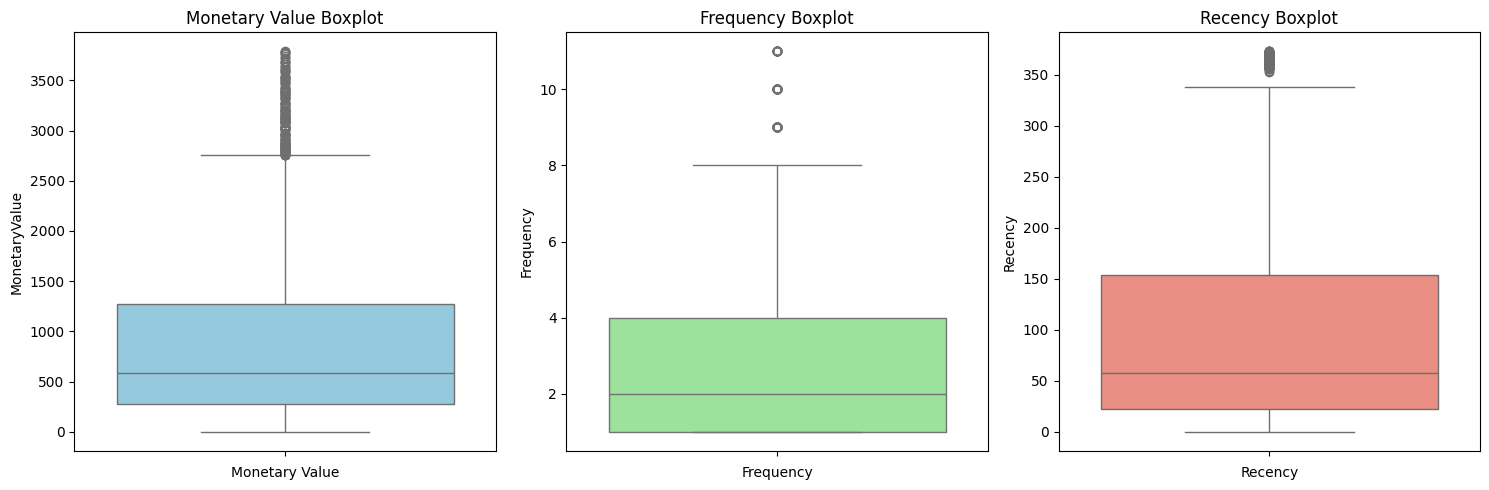

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

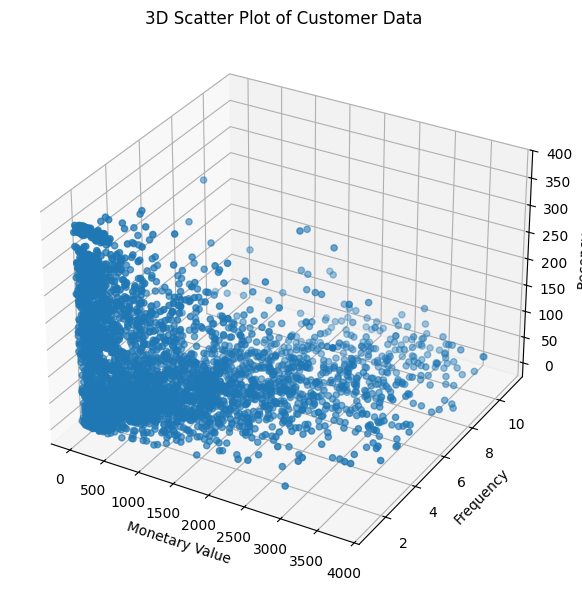

In [ ]:
fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(non_outliers_df["MonetaryValue"], non_outliers_df["Frequency"], non_outliers_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.tight_layout()
plt.show()

Standard scaling transforms the features of your data to have a mean of 0 and a standard deviation of 1, ensuring that each feature contributes equally to the analysis.

$$
z = \frac{x - \mu}{\sigma}
$$

Where:
- $z$ is the standardized value,
- $x$ is the original value,
- $\mu$ is the mean of the feature,
- $\sigma$ is the standard deviation of the feature.

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(non_outliers_df[["MonetaryValue", "Frequency", "Recency"]])

scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.53551442, -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146684, -0.38488934,  0.14187587],
       [ 1.72488782,  0.50659348, -0.81634357]])

In [ ]:
scaled_data_df = pd.DataFrame(scaled_data, index=non_outliers_df.index, columns=("MonetaryValue", "Frequency", "Recency"))

scaled_data_df

,MonetaryValue,Frequency,Recency
0,-0.875945,-0.384889,0.682149
1,0.535514,-0.384889,-0.969251
2,-0.812586,-0.830631,-0.245489
3,1.633678,-0.384889,-0.561498
4,-0.715016,-0.830631,-0.887700
...,...,...,...
4280,-0.298120,1.398076,-0.816344
4281,-0.579553,-0.830631,-0.316846
4282,-0.621972,-0.830631,2.017539
4283,0.441467,-0.384889,0.141876


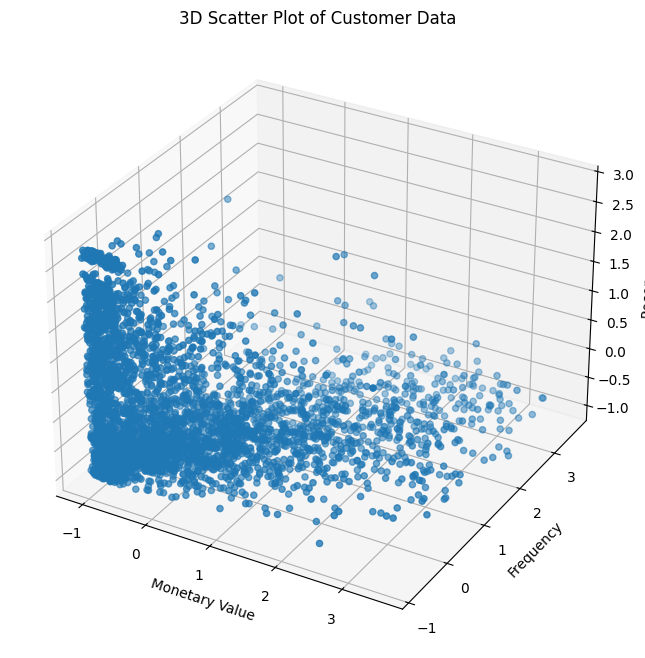

In [ ]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(scaled_data_df["MonetaryValue"], scaled_data_df["Frequency"], scaled_data_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()

### Standard Scaling of RFM Features

Standard scaling is applied to the `MonetaryValue`, `Frequency`, and `Recency` features for the `non_outliers_df`. This transformation standardizes the features to have a mean of 0 and a standard deviation of 1.

**Why standard scaling is important for KMeans:**
*   **Equal Contribution**: KMeans clustering relies on distance calculations. If features have different scales (e.g., MonetaryValue in hundreds/thousands, Frequency in tens, Recency in days), features with larger ranges can dominate the distance metric, making the clusters biased towards those features. Scaling ensures each feature contributes equally to the clustering process.
*   **Improved Performance**: Many machine learning algorithms, including KMeans, perform better when input features are on a similar scale.

## KMeans Clustering

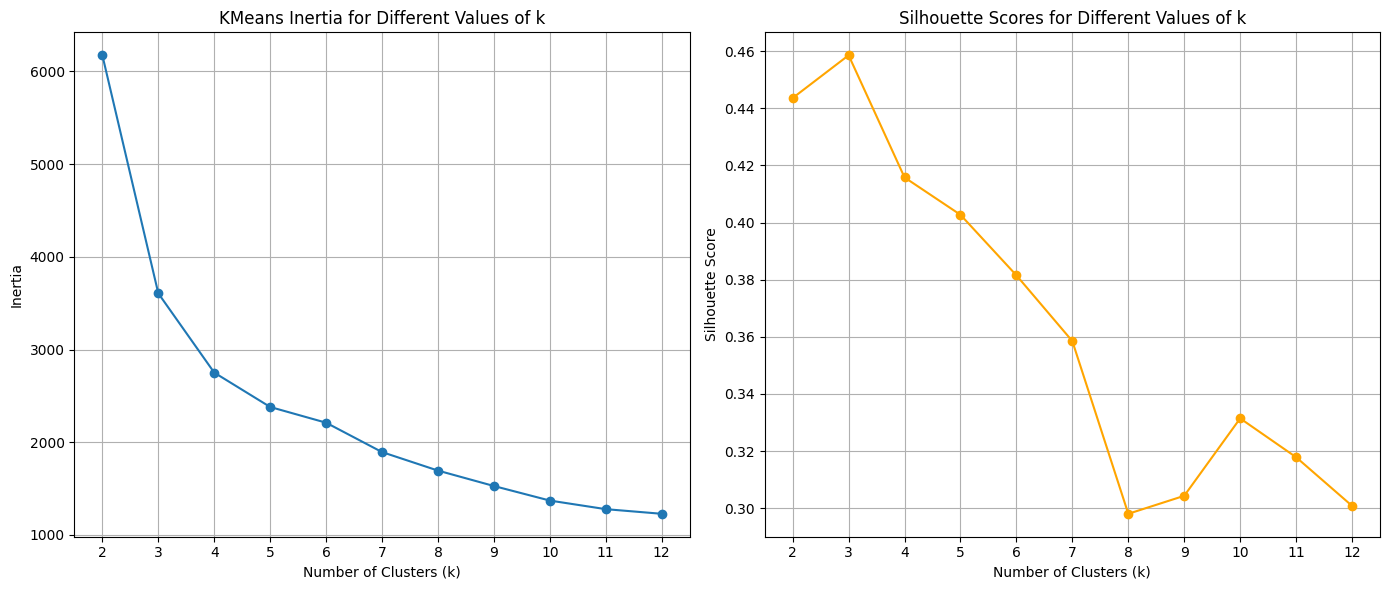

In [ ]:
max_k = 12

inertia = []
silhoutte_scores = []
k_values = range(2, max_k + 1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)

    cluster_labels = kmeans.fit_predict(scaled_data_df)

    sil_score = silhouette_score(scaled_data_df, cluster_labels)

    silhoutte_scores.append(sil_score)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhoutte_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

### Determining Optimal Number of Clusters (KMeans)

We use two methods to determine the optimal number of clusters (`k`) for KMeans:
1.  **Elbow Method (Inertia)**: Plots the inertia (sum of squared distances of samples to their closest cluster center) against the number of clusters. The 'elbow point' in the plot indicates a diminishing return for increasing `k`.
2.  **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters.

**Insights from Elbow and Silhouette Plots:**
*   The **Elbow Method** often shows an 'elbow' around `k=3` or `k=4` where the rate of decrease in inertia significantly slows down.
*   The **Silhouette Score** typically peaks at a certain `k`, suggesting the best separation between clusters. In this case, the silhouette score peaked at `k=3`.

Based on these evaluations, `k=3` is chosen for the KMeans clustering of the non-outlier customers.

### Silhouette Score

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Where:
- $s(i)$ is the silhouette score for a single sample $i$
- $a(i)$ is the average distance between $i$ and all other points in the same cluster,
- $b(i)$ is the minimum average distance between $i$ and all points in the nearest cluster to which $i$ does not belong.

The silhoutte score ranges between $[-1, 1]$, a higher value indicates more distinct clusters.

#"Although Inertia suggested $k=4$, the Silhouette Score peaked at $k=3$, indicating superior cluster separation

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, max_iter=1000)

cluster_labels = kmeans.fit_predict(scaled_data_df)

cluster_labels

array([1, 2, 2, ..., 1, 2, 0], dtype=int32)

### Assigning Clusters to Customers

After determining the optimal number of clusters (`k=3`), we train the KMeans model on the `scaled_data_df` and assign a `Cluster` label to each customer in the `non_outliers_df`. These labels (0, 1, 2) represent the segment each customer belongs to.

In [ ]:
non_outliers_df["Cluster"] = cluster_labels

non_outliers_df

/tmp/ipykernel_4614/3577770544.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df["Cluster"] = cluster_labels


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,169.359995,2,2010-06-28 13:53:00,164,1
1,12347.0,1323.320001,2,2010-12-07 14:57:00,2,2
2,12348.0,221.160004,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.139987,2,2010-10-28 08:23:00,42,0
4,12351.0,300.929998,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.0,641.769997,6,2010-11-22 15:30:00,17,2
4281,18284.0,411.679998,1,2010-10-04 11:33:00,66,2
4282,18285.0,376.999994,1,2010-02-17 10:24:00,295,1
4283,18286.0,1246.429999,2,2010-08-20 11:57:00,111,2


### Visualizing Non-Outlier Clusters in 3D

A 3D scatter plot visualizes the clustered non-outlier customers based on their `MonetaryValue`, `Frequency`, and `Recency`. Each point is colored according to its assigned cluster, allowing for a visual inspection of the cluster separation in the 3D feature space. This helps confirm that the clusters are reasonably distinct.

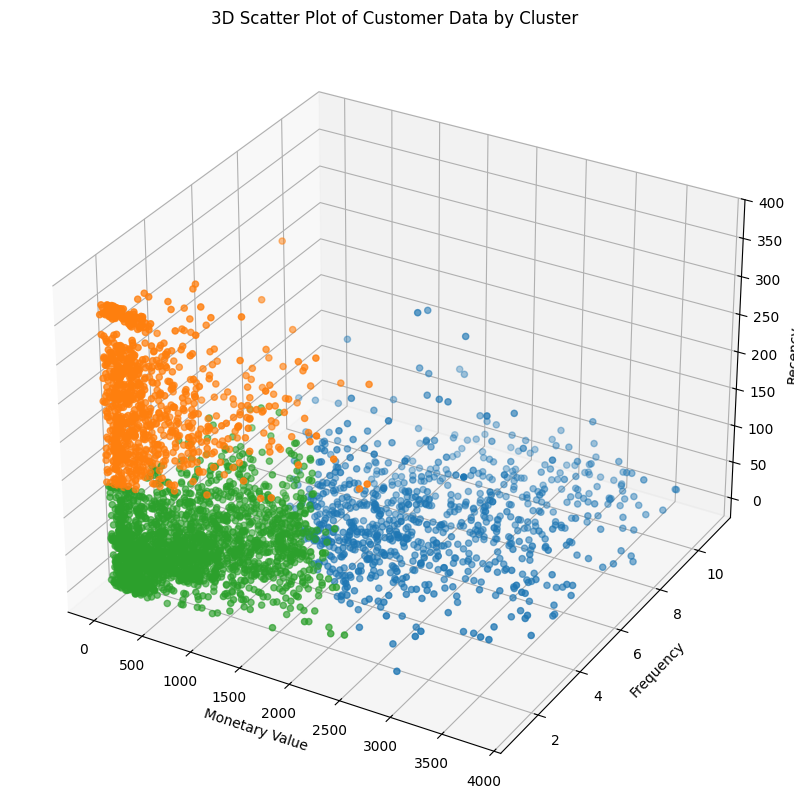

In [ ]:
cluster_colors = {0: '#1f77b4',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c'}  # Green

colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'],
                     non_outliers_df['Frequency'],
                     non_outliers_df['Recency'],
                     c=colors,  # Use mapped solid colors
                     marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

In [ ]:
non_outliers_df.groupby("Cluster")['Cluster'].value_counts()

,count
Cluster,
0,846
1,934
2,2029


### Profiling Non-Outlier Customer Segments

To understand the characteristics of each cluster, we calculate the mean `Recency`, `Frequency`, and `MonetaryValue` for customers within each cluster. These average values help us define and name the customer segments. The `violinplot` for each cluster is also plotted to give better insights about the distribution across clusters for each feature.

In [ ]:
non_outliers_df.groupby("Cluster").agg('mean')

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
Cluster,,,,,
0,15287.267578,2110.332166,6.156028,2010-10-29 20:06:37.375886592,40.716312
1,15467.315430,382.296026,1.431478,2010-04-05 20:41:56.209850112,247.682013
2,15371.869141,606.442753,2.149828,2010-10-19 07:05:38.442582528,51.259241


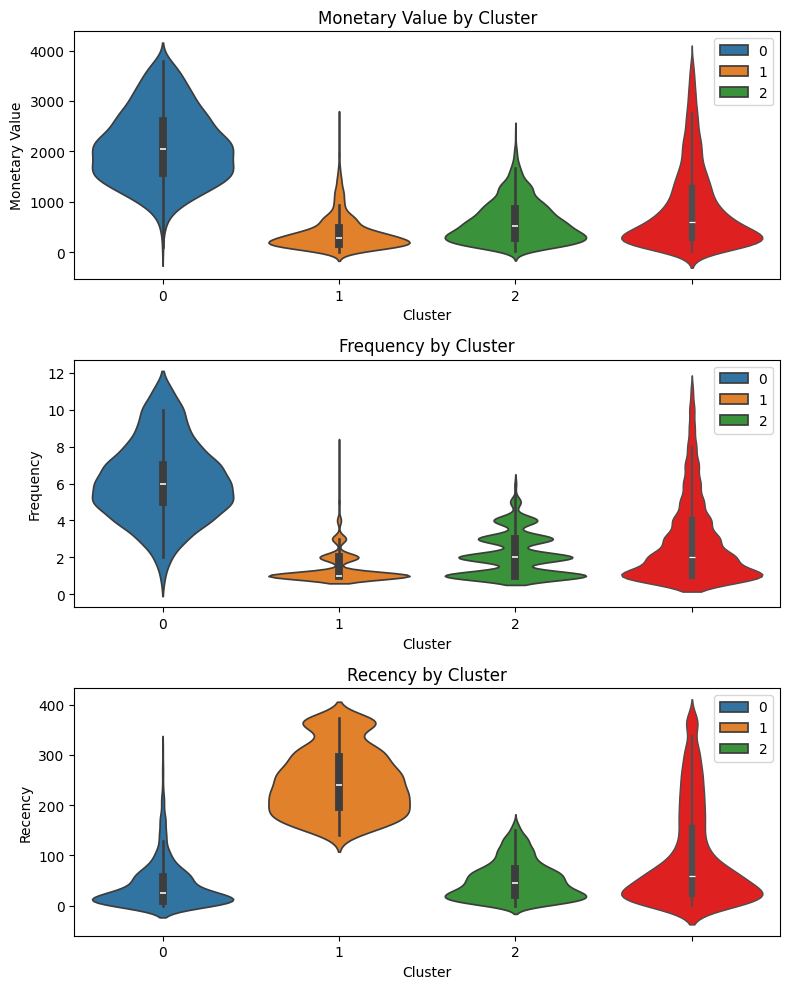

In [ ]:
plt.figure(figsize=(8, 10))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['MonetaryValue'], color='red', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Frequency'], color='red', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')


plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Recency'], color='red', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

### Assigning Outliers to Specialized Segments

The identified outliers (monetary-only, frequency-only, and both monetary and frequency outliers) are assigned unique cluster labels (-1, -2, -3) to distinguish them from the main KMeans clusters. This separate categorization allows for tailored strategies for these extreme customer behaviors.

1. Cluster 0 (Blue): "Retain"
* Rationale: This cluster represents high-value customers with a good frequency. Their **average monetary value is around £2110**, with a **frequency of about 6.16**. Their **recency is moderate (around 41 days)**, indicating they buy regularly but might not have made a very recent purchase. The focus here is on maintaining their loyalty.
* Action: Implement loyalty programs, personalized offers, and regular engagement to ensure they remain active.

2. Cluster 1 (Orange): "Re-Engage"
* Rationale:  These customers have a **low monetary value (around £382) and low frequency (around 1.43). Crucially, they also have the highest recency (around 248 days)**, meaning they haven't purchased for a long time. These customers need strong re-engagement strategies to bring them back.
* Action: Use targeted marketing campaigns, special discounts, or reminders to encourage them to return and purchase again.

3. Cluster 2 (Green): "Nurture"
* Rationale: This is a large group of customers with relatively **low monetary value (around £606) and low frequency (around 2.15). Their recency is also moderate (around 51 days)**, meaning they haven't bought too recently. They need nurturing to increase their engagement and spending.
* Action: Focus on building relationships, providing excellent customer service, and offering incentives to encourage more frequent purchases.

**Summary of Cluster Names:**

* Cluster 0 (Blue): "Retain"
* Cluster 1 (Orange): "Re-Engage"
* Cluster 2 (Green): "Nurture"

In [ ]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])

outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.0,11229.989981,1,2010-11-16 10:05:00,23,-1
25,12380.0,4782.839994,4,2010-08-31 14:54:00,100,-1
42,12409.0,12346.619928,4,2010-10-15 10:24:00,55,-1
48,12415.0,19468.839968,4,2010-11-29 15:07:00,10,-1
61,12431.0,4145.519983,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.0,7516.309950,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.139986,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.829997,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.799952,23,2010-10-29 14:17:00,41,-3


### Profiling Outlier Customer Segments

Similar to the non-outlier clusters, we analyze the mean `Recency`, `Frequency`, and `MonetaryValue` for each outlier cluster. This helps define their unique characteristics and suggests specific engagement strategies. The `violinplot` for each cluster is also plotted to give better insights about the distribution across clusters for each feature. The specific insights and strategies for these are detailed in the subsequent text cell.

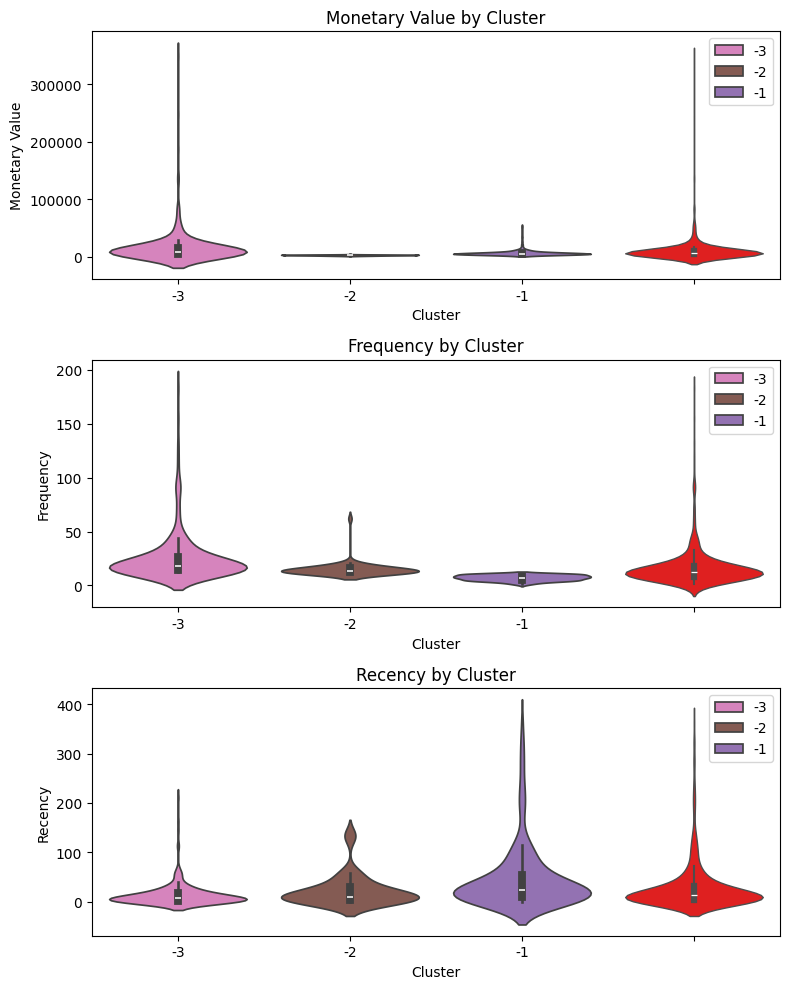

In [ ]:
cluster_colors = {-1: '#9467bd',
                  -2: '#8c564b',
                  -3: '#e377c2'}

plt.figure(figsize=(8, 10))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='red', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='red', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Recency'], color='red', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

### Defining Cluster Labels and Merging All Customers

Descriptive labels are assigned to each cluster based on their RFM characteristics:
*   **RETAIN** (Cluster 0)
*   **RE-ENGAGE** (Cluster 1)
*   **NURTURE** (Cluster 2)
*   **PAMPER** (Cluster -1)
*   **UPSELL** (Cluster -2)
*   **DELIGHT** (Cluster -3)

All customer segments (non-outliers and outliers) are then combined into a single `full_clustering_df`, with a new `ClusterLabel` column, providing a comprehensive view of the customer base.

* Cluster -1 (Monetary Outliers) PAMPER:
* Characteristics: These customers are high-spenders but less frequent buyers. They have a **high average monetary value (around £64.98), but a lower frequency (around 7.19) compared to 'DELIGHT' customers, and their recency is moderate (around 48 days)**. They likely make large, infrequent purchases.
* Potential Strategy: Focus on maintaining their loyalty with personalized offers or luxury services that cater to their high spending capacity.

* Cluster -2 (Frequency Outliers) UPSELL:
* Characteristics: These are frequent buyers but with moderate spending. Their **average frequency is high (around 15.04), and recency is good (around 23 days), but their monetary value is lower (around £27.35)**. They are engaged but could be encouraged to spend more per transaction.
* Potential Strategy: Implement loyalty programs or bundle deals to encourage higher spending per visit, given their frequent engagement.

* Cluster -3 (Monetary & Frequency Outliers) DELIGHT:
* Characteristics: These are your most valuable customers. They have the **highest average monetary value (around £171.48 per 100 pounds), high frequency (around 25.87 purchases), and are quite recent (average recency of about 14 days)**. They are your VIPs who spend a lot and buy often.
* Potential Strategy: Develop VIP programs or exclusive offers to maintain their loyalty and encourage continued engagement.

In [ ]:
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [ ]:
full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,169.359995,2,2010-06-28 13:53:00,164,1
1,12347.0,1323.320001,2,2010-12-07 14:57:00,2,2
2,12348.0,221.160004,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.139987,2,2010-10-28 08:23:00,42,0
4,12351.0,300.929998,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.0,7516.309950,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.139986,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.829997,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.799952,23,2010-10-29 14:17:00,41,-3


In [ ]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,12346.0,169.359995,2,2010-06-28 13:53:00,164,1,RE-ENGAGE
1,12347.0,1323.320001,2,2010-12-07 14:57:00,2,2,NURTURE
2,12348.0,221.160004,1,2010-09-27 14:59:00,73,2,NURTURE
3,12349.0,2221.139987,2,2010-10-28 08:23:00,42,0,RETAIN
4,12351.0,300.929998,1,2010-11-29 15:23:00,10,2,NURTURE
...,...,...,...,...,...,...,...
4235,18223.0,7516.309950,12,2010-11-17 12:20:00,22,-3,DELIGHT
4236,18225.0,7545.139986,15,2010-12-09 15:46:00,0,-3,DELIGHT
4237,18226.0,6650.829997,15,2010-11-26 15:51:00,13,-3,DELIGHT
4241,18231.0,4791.799952,23,2010-10-29 14:17:00,41,-3,DELIGHT


### Visualizing Cluster Distribution and Mean Feature Values

This final visualization presents a dual-axis plot:

*   **Bar Plot (Left Y-axis)**: Shows the number of customers in each `ClusterLabel`, indicating the size of each segment.
*   **Line Plot (Right Y-axis)**: Displays the average `Recency`, `Frequency`, and scaled `MonetaryValue` (per 100 pounds) for each cluster.

**Overall Insight:**
This plot provides a clear summary of the customer segmentation. It allows us to quickly compare the size and characteristics of each segment, which is crucial for developing targeted marketing and business strategies. For instance, the 'NURTURE' cluster is the largest, indicating a significant opportunity for growth, while 'DELIGHT' represents the most valuable but smallest segment requiring premium engagement.

## Visualisation

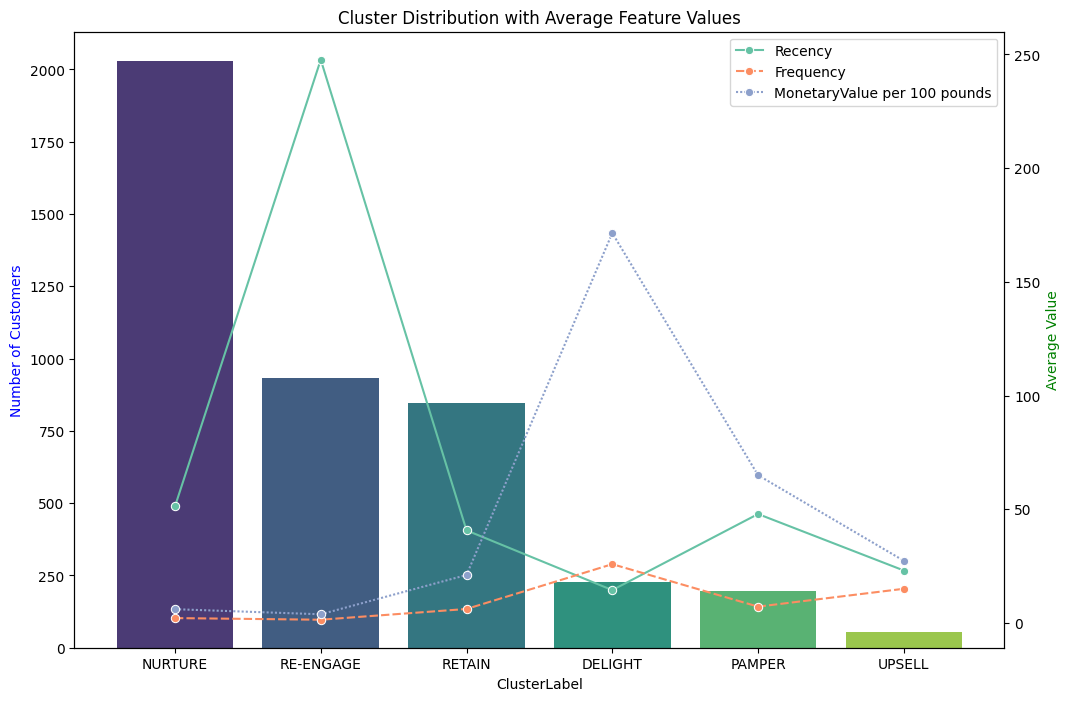

In [ ]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"] / 100.00
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()

## Revenue Contribution by Segment

This table answers the key business question: **which customer segments are actually driving revenue?**
Each segment's share of total revenue, average order value, and recency is shown — this is the "so what" a business stakeholder actually needs.


In [ ]:
# Revenue contribution per segment
revenue_summary = full_clustering_df.groupby("ClusterLabel").agg(
    Customer_Count=("MonetaryValue", "count"),
    Total_Revenue=("MonetaryValue", "sum"),
    Avg_Order_Value=("MonetaryValue", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Recency_Days=("Recency", "mean")
).reset_index()

total_rev = revenue_summary["Total_Revenue"].sum()
revenue_summary["Revenue_Share_%"] = (revenue_summary["Total_Revenue"] / total_rev * 100).round(1)
revenue_summary["Total_Revenue"] = revenue_summary["Total_Revenue"].round(2)
revenue_summary["Avg_Order_Value"] = revenue_summary["Avg_Order_Value"].round(2)
revenue_summary["Avg_Frequency"] = revenue_summary["Avg_Frequency"].round(1)
revenue_summary["Avg_Recency_Days"] = revenue_summary["Avg_Recency_Days"].round(0).astype(int)

# Sort by revenue share descending
revenue_summary = revenue_summary.sort_values("Revenue_Share_%", ascending=False).reset_index(drop=True)

print(f"Total Revenue across all segments: £{total_rev:,.2f}")
print()
revenue_summary


Total Revenue across all segments: £8,673,383.29



,ClusterLabel,Customer_Count,Total_Revenue,Avg_Order_Value,Avg_Frequency,Avg_Recency_Days,Revenue_Share_%
0,DELIGHT,226,3875372.00,17147.66,25.9,14,44.7
1,RETAIN,846,1785341.01,2110.33,6.2,41,20.6
2,PAMPER,197,1280195.01,6498.45,7.2,48,14.8
3,NURTURE,2029,1230472.35,606.44,2.1,51,14.2
4,RE-ENGAGE,934,357064.49,382.30,1.4,248,4.1
5,UPSELL,53,144938.44,2734.69,15.0,23,1.7


In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(x=full_clustering_df)

## Summary

Graphs of all 6 customer segments — size, revenue contribution, and engagement metrics.


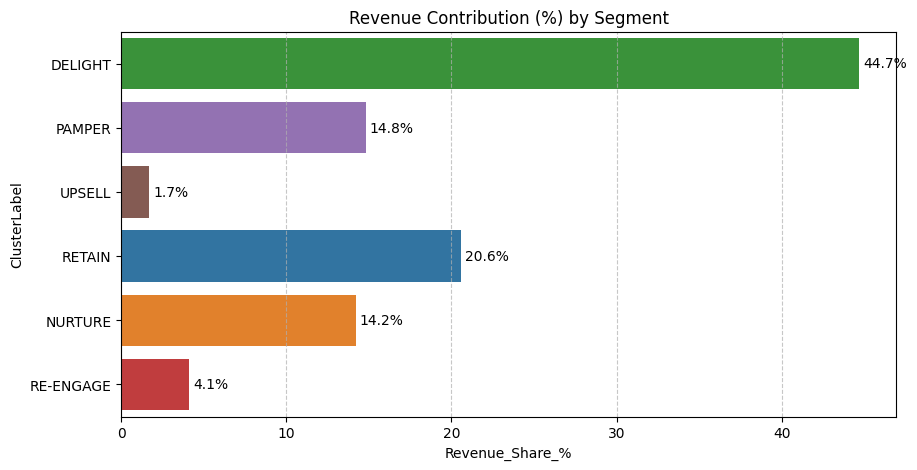

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define segment order and colors for consistency
seg_order = ['DELIGHT', 'PAMPER', 'UPSELL', 'RETAIN', 'NURTURE', 'RE-ENGAGE']
seg_colors = {'DELIGHT': '#2ca02c', 'PAMPER': '#9467bd', 'UPSELL': '#8c564b', 'RETAIN': '#1f77b4', 'NURTURE': '#ff7f0e', 'RE-ENGAGE': '#d62728'}

# 1. Revenue Share per Segment
plt.figure(figsize=(10, 5))
a = sns.barplot(data=revenue_summary, x='Revenue_Share_%', y='ClusterLabel', order=seg_order, palette=seg_colors, hue='ClusterLabel', legend=False)

# Add percentage labels to all containers
for container in a.containers:
    a.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Revenue Contribution (%) by Segment')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

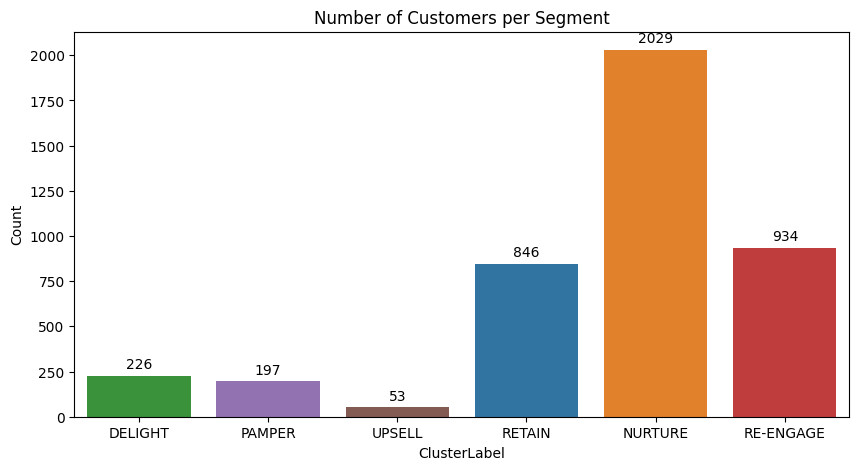

In [ ]:
# 2. Customer Count per Segment
plt.figure(figsize=(10, 5))
a = sns.barplot(data=revenue_summary, x='ClusterLabel', y='Customer_Count', order=seg_order, palette=seg_colors, hue='ClusterLabel', legend=False)

# Add labels to the bars
for container in a.containers:
    a.bar_label(container, padding=3)

plt.title('Number of Customers per Segment')
plt.ylabel('Count')
plt.show()

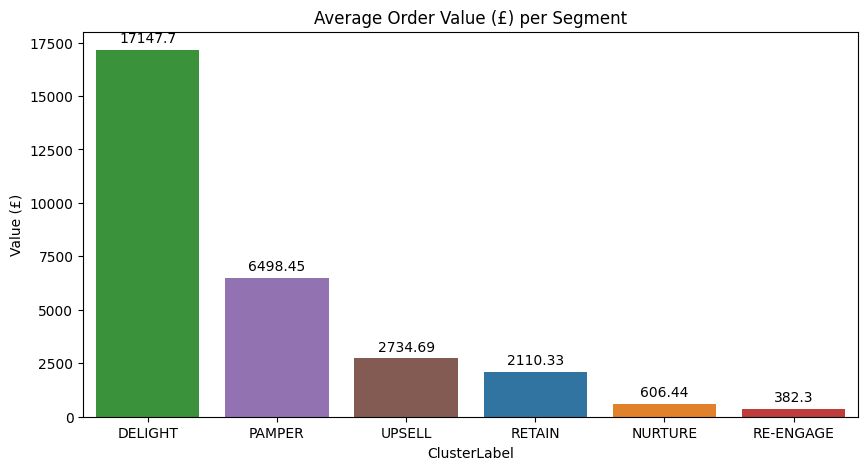

In [ ]:
# 3. Average Order Value per Segment
plt.figure(figsize=(10, 5))
a = sns.barplot(data=revenue_summary, x='ClusterLabel', y='Avg_Order_Value', order=seg_order, palette=seg_colors, hue='ClusterLabel', legend=False)
for container in a.containers:
    a.bar_label(container, padding=3)
plt.title('Average Order Value (£) per Segment')
plt.ylabel('Value (£)')
plt.show()

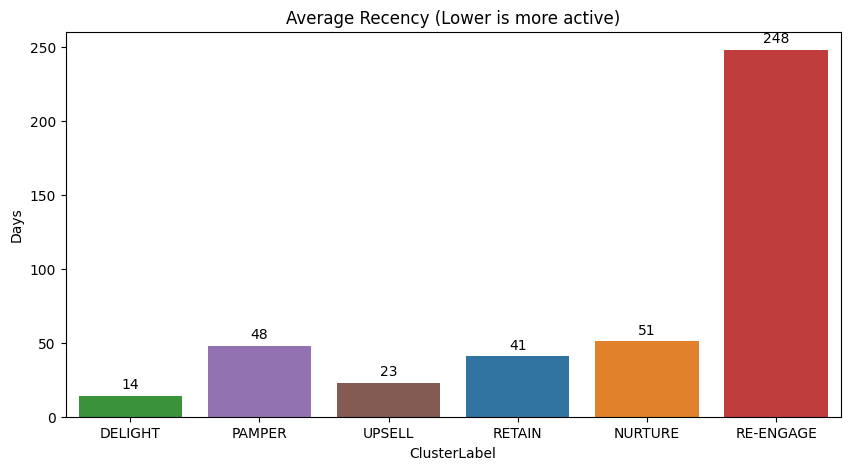

In [ ]:
# 4. Recency (Days since last purchase)
plt.figure(figsize=(10, 5))
a = sns.barplot(data=revenue_summary, x='ClusterLabel', y='Avg_Recency_Days', order=seg_order, palette=seg_colors, hue='ClusterLabel', legend=False)
for container in a.containers:
    a.bar_label(container, padding=3)
plt.title('Average Recency (Lower is more active)')
plt.ylabel('Days')
plt.show()

## Key Takeaways & Business Recommendations

| Segment | Priority | Recommended Action |
|---------|----------|--------------------|
| **DELIGHT** | 🔴 Critical | VIP program, dedicated account manager, early access to new products |
| **PAMPER** | 🔴 High | Luxury/high-value promotions, upsell premium bundles |
| **UPSELL** | 🟠 High | Loyalty points, bundle deals — they buy often, encourage higher spend |
| **RETAIN** | 🟠 Medium | Monthly newsletters, personalised recommendations, loyalty tier |
| **NURTURE** | 🟡 Medium | Onboarding email sequence, first-purchase follow-up discount |
| **RE-ENGAGE** | ⚪ Low | Win-back campaign with strong discount — if no response, deprioritise |

**Bottom line:** Focus 80% of CRM budget on DELIGHT + PAMPER + UPSELL segments — they drive the most revenue with the highest engagement. RE-ENGAGE customers require the most effort for the least return.
